In [ ]:
!pip install transformers diffusers accelerate


In [ ]:

from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler
import torch

model_id = "../stable-diffusion-2-base"

# Use the Euler scheduler here instead
scheduler = EulerDiscreteScheduler.from_pretrained(model_id, subfolder="scheduler")
pipe = StableDiffusionPipeline.from_pretrained(model_id, scheduler=scheduler, torch_dtype=torch.float32)
pipe = pipe.to("cpu")

prompt = "a photo of an astronaut riding a horse on mars"
image = pipe(prompt).images[0]  
    
image.save("astronaut_rides_horse.png")

In [ ]:
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# 1. טעינת ה-Pipeline הייעודי ל-Inpainting
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype
)
pipe.to(device)

init_image = Image.open("blue-cow.png").convert("RGB").resize((512, 512))
mask_image = Image.open("magen_david_mask.png").convert("RGB").resize((512, 512))

# 3. הגדרת הפרומפט - מה נרצה להוסיף באזור הלבן?
prompt = "a giraffe doll sitting on chair"

# 4. הרצה
# num_inference_steps: כמות הצעדים (20-50 זה סבבה)
# strength: כמה לשנות את האזור המסומן (1.0 זה שינוי מוחלט)
result_image = pipe(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image,
    num_inference_steps=30
).images[0]

# 5. שמירה
result_image.save("inpainting_result.png")
print("Inpainting finished! check inpainting_result.png")

In [ ]:
from PIL import Image
from diffusers import StableDiffusionInpaintPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# 1. טעינת ה-Pipeline הייעודי ל-Inpainting
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype
)
pipe.to(device)

init_image = Image.open("blue-cow.png").convert("RGB").resize((512, 512))
mask_image = Image.open("magen_david_mask.png").convert("RGB").resize((512, 512))

# 3. הגדרת הפרומפט - מה נרצה להוסיף באזור הלבן?
prompt = "a giraffe doll sitting on chair"

# 4. הרצה
# num_inference_steps: כמות הצעדים (20-50 זה סבבה)
# strength: כמה לשנות את האזור המסומן (1.0 זה שינוי מוחלט)
result_image = pipe(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image,
    num_inference_steps=30
).images[0]

# 5. שמירה
result_image.save("real_inpainting_result.png")
print("Inpainting finished! check inpainting_result.png")

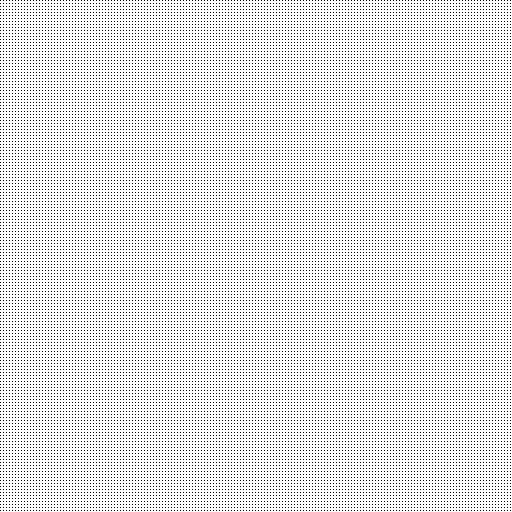

In [2]:
import numpy as np
from PIL import Image

def create_grid_mask(k, width=512, height=512):
    mask_array = np.full((height, width), 255, dtype=np.uint8)
    mask_array[::k, ::k] = 0
    return Image.fromarray(mask_array).convert("L")

create_grid_mask(3)
    

In [ ]:
from PIL import Image
from diffusers import StableDiffusionInpaintPipeline
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

model_id = "../stable-diffusion-2-base"

# 1. טעינת ה-Pipeline הייעודי ל-Inpainting
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype
)
pipe.to(device)
init_image = Image.open("lemon.png").convert("RGB").resize((512, 512))
prompt_repare = "a cut lemon on a dark reflective surface"
prompt_repaint = "a cut apple on a dark reflective surface"



for k in range(2,9):
    print(k)
    mask_image = create_grid_mask(k)


    result_image = pipe(
        prompt=prompt_repare,
        image=init_image,
        mask_image=mask_image,
        num_inference_steps=30
    ).images[0]

    result_image.save(f"repair_with_k={k}.png")
    
    result_image = pipe(
        prompt=prompt_repaint,
        image=init_image,
        mask_image=mask_image,
        num_inference_steps=30
    ).images[0]

    result_image.save(f"repaint_with_k={k}.png")
    print(f"Inpainting finished! for {k} factor. check inpainting_result.png")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

2


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]